In [1]:
import os
import sys
import site
import ctypes
from pathlib import Path

def force_load_nvrtc():
    site_dirs = site.getsitepackages()
    found_lib = None
    
    for s_dir in site_dirs:
        # Path based on your verified location
        potential_path = Path(s_dir) / "nvidia" / "cu13" / "lib" / "libnvrtc-builtins.so.13.0"
        if potential_path.exists():
            found_lib = potential_path
            break
            
    if found_lib:
        # Force the OS to load the library into the current process memory
        # RTLD_GLOBAL makes the symbols available to other libraries (like Torch)
        try:
            ctypes.CDLL(str(found_lib), mode=ctypes.RTLD_GLOBAL)
            print(f"✅ Manually loaded: {found_lib}")
        except Exception as e:
            print(f"❌ Failed to load {found_lib}: {e}")
    else:
        print("❌ libnvrtc-builtins.so.13.0 not found in site-packages.")

force_load_nvrtc()

import torch
# ... rest of your code

import torch
try:
    # Test compilation immediately to see if it works
    print(f"Torch CUDA version: {torch.version.cuda}")
    print(f"NVRTC test: {torch.cuda.is_available()}")
except Exception as e:
    print(f"⚠️ Still failing: {e}")

✅ Manually loaded: /home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0
Torch CUDA version: 13.0
NVRTC test: True


In [2]:
from mace.calculators import MACECalculator
import numpy as np
import pandas as pd
import ase
from ase import Atom, Atoms

from ase.build import graphene
from ase.optimize import BFGS

from ase.filters import ExpCellFilter, FrechetCellFilter

from ase.visualize import view

from ase.io import write

import matplotlib.pyplot as plt

from tqdm import tqdm


/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [3]:
model = MACECalculator("../../MACE.model", device = "cuda", cu_equivariance = True)

/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.


/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/new_sources/mace_custom/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [4]:
def generate_primitive(latticeparam=2.46):
    a = latticeparam

    # Primitive vectors rotated 30° relative to your original.
    # a1 points at 30°, a2 points at 90° — armchair direction is now along X.
    cell = np.array([
        [0.5 * np.sqrt(3) * a,  0.5 * a, 0],   # a1 at 30°
        [0,                      a,       0],   # a2 at 90°
        [0,                      0,      20.0]
    ])

    # Same fractional coordinates as your original — still valid graphene
    positions_frac = np.array([
        [1/3, 1/3, 0],
        [2/3, 2/3, 0]
    ])

    xyz_positions = positions_frac @ cell

    atoms = Atoms("C2",
                  positions=xyz_positions,
                  cell=cell,
                  pbc=(True, True, False))

    return atoms

In [5]:
primitive = generate_primitive(2.4598288248992755)
primitive.rattle(stdev=0.01)
primitive.calc = model
cell_filter = FrechetCellFilter(primitive, mask = [1,1,0,0,0,1])


opt = BFGS(cell_filter)

opt.run(fmax = 1e-4)

a0 = np.linalg.norm(primitive.cell.copy()[0])
l0 = a0 / np.sqrt(3)


view(primitive.repeat((5,5,1)), viewer="ngl")

      Step     Time          Energy          fmax
BFGS:    0 12:30:38      -15.913748        0.570228
BFGS:    1 12:30:38      -15.916229        0.301324
BFGS:    2 12:30:38      -15.917133        0.052656
BFGS:    3 12:30:38      -15.917200        0.023476
BFGS:    4 12:30:38      -15.917215        0.003021
BFGS:    5 12:30:38      -15.917213        0.000379
BFGS:    6 12:30:38      -15.917210        0.000353
BFGS:    7 12:30:38      -15.917213        0.000291
BFGS:    8 12:30:38      -15.917213        0.000342
BFGS:    9 12:30:38      -15.917213        0.000131
BFGS:   10 12:30:38      -15.917215        0.000026


In [6]:
rep_primitive = primitive.repeat((2,2,1))

hessian=model.get_hessian(atoms = rep_primitive)

In [7]:
KCELL0 = 3*l0* np.array([
    [1,0,0],
    [0.5, np.sqrt(3)/2, 0],
    [0,0,100]
])
# in K cell 0 primitive direction
KBASE0 = (1/3.) * np.array([
    [1, 0, 0],
    [2, 0, 0],
    [2, 1, 0],
    [1, 2, 0],
    [0, 1, 0],
    [0, 2, 0]
])

katoms = Atoms("C6", positions = KBASE0 @ KCELL0, cell=KCELL0, pbc = [True, True, True])


In [8]:
opt = BFGS(atoms=katoms)
katoms.calc = model
opt.run(fmax = 1e-5)

      Step     Time          Energy          fmax
BFGS:    0 12:30:40      -47.751644        0.000020
BFGS:    1 12:30:40      -47.751648        0.000025
BFGS:    2 12:30:40      -47.751644        0.000011
BFGS:    3 12:30:40      -47.751644        0.000013
BFGS:    4 12:30:40      -47.751648        0.000024
BFGS:    5 12:30:40      -47.751648        0.000024
BFGS:    6 12:30:40      -47.751648        0.000120
BFGS:    7 12:30:40      -47.751648        0.000014
BFGS:    8 12:30:40      -47.751652        0.000014
BFGS:    9 12:30:40      -47.751644        0.000022
BFGS:   10 12:30:40      -47.751648        0.000030
BFGS:   11 12:30:40      -47.751644        0.000016
BFGS:   12 12:30:40      -47.751648        0.000020
BFGS:   13 12:30:40      -47.751648        0.000017
BFGS:   14 12:30:40      -47.751644        0.000032
BFGS:   15 12:30:40      -47.751652        0.000011
BFGS:   16 12:30:40      -47.751644        0.000021
BFGS:   17 12:30:40      -47.751644        0.000011
BFGS:   18 12:

np.True_

In [9]:
strains = np.linspace(2, 0.3, 30)
strains_tensors = [np.array([
    [s, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
]) for s in strains]
id = np.eye(3)
deformations = [id + s for s in strains_tensors]

In [10]:
def frobenius(matrices):
    return np.sum(matrices**2, axis=(-2, -1))

In [11]:
def angles_deg(vecs1, vecs2):
    """
    Computes the angle in degrees between two sets of vectors.
    Supports both single vectors and arrays of vectors.
    """
    # Ensure they are numpy arrays
    v1 = np.array(vecs1)
    v2 = np.array(vecs2)

    # Normalize the vectors to unit length (magnitude 1)
    # axis=-1 handles both 1D vectors and (N, dim) arrays
    v1_u = v1 / np.linalg.norm(v1, axis=-1, keepdims=True)
    v2_u = v2 / np.linalg.norm(v2, axis=-1, keepdims=True)

    # Calculate dot product. Use clip to stay within [-1.0, 1.0] 
    # to avoid NaNs from floating point precision noise.
    dot = np.sum(v1_u * v2_u, axis=-1)
    dot = np.clip(dot, -1.0, 1.0)

    # Convert to degrees
    return np.degrees(np.arccos(dot))

In [12]:
import numpy as np
from ase.optimize import BFGS
from ase.constraints import FixedPlane

# Correct Voigt basis: engineering shear uses ½ off-diagonal
VOIGT_BASIS_2D = np.array([
    [[1, 0, 0], [0, 0, 0], [0, 0, 0]],           # xx
    [[0, 0, 0], [0, 1, 0], [0, 0, 0]],           # yy  ← was [0,1,0] in row 0; wrong
    [[0, 0.5, 0], [0.5, 0, 0], [0, 0, 0]],       # xy  ← was 1.0; must be 0.5
], dtype=float)


def freeze_z(atoms):
    """Add FixedPlane constraints so no atom moves in Z."""
    constraints = [FixedPlane(i, [0, 0, 1]) for i in range(len(atoms))]
    atoms.set_constraint(constraints)


def rattle_2d(atoms, stdev=1e-4):
    """
    Displace atoms randomly in X/Y only — call BEFORE deformation.
    Keep stdev well below the strain step (default 1e-3) so the
    perturbation doesn't dominate the finite-difference signal.
    """
    pos = atoms.get_positions()
    noise = np.random.normal(0, stdev, (len(atoms), 2))

    pos[:, :2] += noise
    atoms.set_positions(pos)

    return atoms

def hessian_2d(atoms, model, step=1e-3, fmax=1e-5, rattle_stdev=1e-4):
    """
    3x3 in-plane stiffness matrix for a 2D material (eV/Å²).

    Uses central finite differences:
        C[i,j] = d s_j / d ε_i  ≈  (s_j(+h) - s_j(-h)) / 2h

    Reference stress is computed once from the input atoms (assumed
    fully relaxed). Atoms are rattled before deformation to break
    accidental symmetry, and Z motion is frozen throughout.
    """
    cell0 = atoms.get_cell().copy()
    ase_indices = [0, 1, 5]  # xx, yy, xy in ASE Voigt order

    # L_z: vacuum + thickness — needed to convert 3D → 2D stress
    # L_z = cell0[2, 2]

    C_2d = np.zeros((3, 3))

    for i in range(3):
        stresses = []
        for sign in (+1, -1):  # central difference: both directions
            work_atoms = atoms.copy()
            work_atoms.calc = model

            # 1. Rattle BEFORE deformation (tiny, just symmetry breaking)
            rattle_2d(work_atoms, stdev=rattle_stdev)

            # 2. Apply in-plane strain
            deformation = np.eye(3) + sign * step * VOIGT_BASIS_2D[i]
            work_atoms.set_cell(cell0 @ deformation, scale_atoms=True)

            # 3. Freeze Z so relaxation stays strictly 2D
            freeze_z(work_atoms)

            # 4. Relax in-plane degrees of freedom
            with BFGS(work_atoms, logfile=None) as opt:
                opt.run(fmax=fmax, steps=1000)

            vol = work_atoms.get_volume()

            # 5. Extract stress and convert to 2D units (eV/Å²)
            stress_3d = work_atoms.get_stress(voigt=True)  # eV/Å³
            stress_2d = stress_3d * vol                    # eV
            stresses.append(stress_2d[ase_indices])

        # Central finite difference: O(h²) accuracy, no bias
        C_2d[i] = (stresses[0] - stresses[1]) / (2 * step)

    # Enforce symmetry
    return (C_2d + C_2d.T) / 2.0

In [13]:
cell_inv = np.linalg.inv(primitive.get_cell())
positions = primitive.get_positions()
relative_positions = positions @ cell_inv

print(positions)
print(relative_positions)
print(relative_positions @ primitive.get_cell())

[[7.20189999e-01 1.22805036e+00 2.06776826e-03]
 [1.43028098e+00 2.45796217e+00 2.06774809e-03]]
[[3.38073955e-01 3.30206114e-01 1.03388413e-04]
 [6.71407195e-01 6.63539324e-01 1.03387404e-04]]
[[7.20189999e-01 1.22805036e+00 2.06776826e-03]
 [1.43028098e+00 2.45796217e+00 2.06774809e-03]]


In [20]:
# ── Correct comparison test ──────────────────────────────────────────────────
# Always evaluate both methods on the RELAXED primitive cell.
# Never pre-strain before comparing.

from ase.optimize import BFGS

# 1. Start from relaxed primitive, only set vacuum
ref_atoms = primitive.copy()

test_strain = np.array([
    [0.15, 0.3, 0],
    [0.3, 0.7, 0],
    [0, 0, 0]
])

test_strain = 0.01 * test_strain / np.sqrt(frobenius(test_strain))

test_deformation = np.eye(3) + test_strain
ref_atoms.set_cell(ref_atoms.get_cell() @ test_deformation, scale_atoms=True)

ref_atoms.cell[2, 2] = 20.0
ref_atoms.calc = model

# 2. Relax fully first
with BFGS(ref_atoms, logfile=None) as opt:
    opt.run(fmax=1e-5)

cell_hessian = model.get_hessian_cell(atoms=ref_atoms, two_d = True)
print("Cell Hessian (2D):")
print(cell_hessian)

eigenvalues, eigenvectors = torch.linalg.eig(cell_hessian.reshape(4, 4))
print("Eigenvalues:")
print(eigenvalues)
print("Eigenvectors:")
print(eigenvectors)

tensor([[[[[ 5.6907e+00, -3.8620e-02,  2.6959e-10],
           [ 5.6963e+00, -3.8659e-02,  2.6986e-10],
           [-2.9610e-09,  1.3937e-11,  1.1398e-19]],

          [[-3.8617e-02,  5.6185e+00,  2.9089e-10],
           [-3.8655e-02,  5.6241e+00,  2.9117e-10],
           [ 2.7874e-11, -2.0992e-09,  7.9577e-20]],

          [[ 2.6959e-10,  2.9090e-10,  1.8005e+00],
           [ 2.6985e-10,  2.9119e-10,  1.8023e+00],
           [-8.2072e-20, -1.2744e-19, -7.6388e-10]]],


         [[[ 5.6963e+00, -3.8659e-02,  2.6986e-10],
           [ 5.7020e+00, -3.8697e-02,  2.7012e-10],
           [-2.9076e-09,  1.4720e-11,  1.1228e-19]],

          [[-3.8655e-02,  5.6241e+00,  2.9117e-10],
           [-3.8694e-02,  5.6296e+00,  2.9146e-10],
           [ 2.7469e-11, -2.1293e-09,  8.2475e-20]],

          [[ 2.6985e-10,  2.9119e-10,  1.8023e+00],
           [ 2.7012e-10,  2.9147e-10,  1.8041e+00],
           [-8.8482e-20, -1.1984e-19, -7.4857e-10]]],


         [[[-2.7148e-09,  4.3460e-11,  1.5074e-1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import FancyArrowPatch
from ase.optimize import BFGS
from tqdm import tqdm


# ── colour palette (perceptually ordered, colourblind-friendly) ──────────────
_CMAP_STRAIN = "plasma"
_C = dict(xx="#e05c4b", yy="#4b8fe0", xy="#50b96a",
          frob="black", emin="#9c59d1", emax="#e09a2b")


def _angles_deg(v1: np.ndarray, v2: np.ndarray) -> np.ndarray:
    """Signed angle (degrees) from v1[:,i] to v2[:,i], in [-180, 180]."""
    cos = np.einsum("ij,ij->i", v1, v2)
    sin = v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0]
    return np.degrees(np.arctan2(sin, np.clip(cos, -1, 1)))


def stress_strain(
    strain_template,
    atoms,
    strains=np.linspace(0.15, 0.30),
    supercell=(1, 1, 1),
):
    """
    Compute 2-D stress tensor vs applied strain, then derive eigensystem
    and angles.  All eigenvalues and eigenvectors are sorted in **ascending
    eigenvalue order** at every strain step, with a continuity sign fix.

    Returns
    -------
    strains : ndarray (N,)
    stresses : ndarray (N, 2, 2)
    """
    cell0 = atoms.cell.copy()
    id3 = np.eye(3)
    stresses_all = []

    hessians = []

    for s in tqdm(strains, desc="strain loop"):
        deform = id3 + (strain_template * s)
        cell = cell0 @ deform
        strained_atoms = atoms.copy()
        strained_atoms = strained_atoms.repeat(supercell)
        strained_atoms.set_cell(cell, scale_atoms=True)
        strained_atoms.pbc = (True, True, True)
        strained_atoms.calc = model          # `model` must be defined in outer scope
        strained_atoms.rattle(stdev=1e-2)
        opt = BFGS(strained_atoms, logfile=None)
        opt.run(fmax=1e-4, steps = 1000)
        stress_3d = strained_atoms.get_stress(voigt=False)
        stresses_all.append(stress_3d[:2, :2])

        hessians.append(hessian_2d(strained_atoms, model))

    stresses = np.array(stresses_all)        # (N, 2, 2)
    nstrains = len(strains)
    frob_norms = np.sum(stresses ** 2, axis=(1, 2))
    hessians = np.array(hessians)

    h_vals = np.linalg.eigvalsh(hessians)


    # ── Eigensystem ──────────────────────────────────────────────────────────
    # np.linalg.eigh returns:
    #   e_vals : (N, 2)   – already ascending per row (eigh guarantee)
    #   e_vecs : (N, 2, 2) – columns are eigenvectors:
    #                         e_vecs[i, :, k] is the k-th eigenvector at strain i
    e_vals, e_vecs = np.linalg.eigh(stresses)  # ascending order guaranteed

    # ── BUG FIX: eigh already gives ascending order, but verify and re-sort
    # per strain just to be safe (and to be explicit for non-symmetric inputs).
    # Correct indexing: for each strain i, sort the 2 eigenvalue columns.
    for i in range(nstrains):
        order = np.argsort(e_vals[i])          # indices that sort THIS strain's evals
        e_vals[i] = e_vals[i, order]            # reorder eigenvalues in-place
        e_vecs[i] = e_vecs[i][:, order]         # reorder eigenvector COLUMNS in-place

    # ── Continuity fix on eigenvector sign ───────────────────────────────────
    v_min = np.zeros((nstrains, 2))
    v_max = np.zeros((nstrains, 2))

    for i in range(nstrains):
        vm = e_vecs[i, :, 0].copy()   # eigenvector for smaller eigenvalue
        vM = e_vecs[i, :, 1].copy()   # eigenvector for larger  eigenvalue

        if (vm[0] < 0 and vm[1]< 0) or (vm[0] > 0 and vm[1] <0):
            vm *= -1
        if (vM[0] < 0 and vM[1]< 0) or (vM[0] > 0 and vM[1] <0):
            vM *= -1

        v_min[i] = vm
        v_max[i] = vM

    # ── Derived angles ───────────────────────────────────────────────────────
    angle_min_x = np.degrees(np.arctan2(v_min[:, 1], v_min[:, 0]))
    angle_max_x = np.degrees(np.arctan2(v_max[:, 1], v_max[:, 0]))
    angle_min_max = _angles_deg(v_min, v_max)

    # ── Derivatives ──────────────────────────────────────────────────────────
    der_strains = np.diff(strains)
    der_stress = np.diff(stresses, axis=0) / der_strains[:, np.newaxis, np.newaxis]
    der_eighs = np.diff(e_vals, axis = 0) / der_strains[:, np.newaxis]
    strain_mid = 0.5 * (strains[:-1] + strains[1:])

    # full hessian


    # ════════════════════════════════════════════════════════════════════════
    #  ENHANCED FIGURES
    # ════════════════════════════════════════════════════════════════════════
    strain_norm = plt.Normalize(strains.min(), strains.max())
    cmap_strain = plt.get_cmap(_CMAP_STRAIN)
    sm = ScalarMappable(cmap=cmap_strain, norm=strain_norm)
    sm.set_array([])


    plt.rcParams.update({
        "font.family": "sans-serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.framealpha": 0.92,
        "legend.edgecolor": "0.85",
        "legend.fontsize": 9,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    # ── Fig 1 : Stress components + Frobenius norm ───────────────────────────
    fig1, ax1 = plt.subplots(figsize=(8, 3.6))
    fig1.subplots_adjust(right=0.82)

    ax1.plot(strains, stresses[:, 0, 0], color=_C["xx"], lw=1.8,
             label=r"$\sigma_{xx}$")
    ax1.plot(strains, stresses[:, 1, 1], color=_C["yy"], lw=1.8,
             label=r"$\sigma_{yy}$")
    ax1.plot(strains, stresses[:, 0, 1], color=_C["xy"], lw=1.8,
             ls="--", label=r"$\sigma_{xy}$")
    ax1.axhline(0, color="0.6", lw=0.6, ls=":")
    ax1.set_xlabel("Applied strain  $\\varepsilon$")
    ax1.set_ylabel(r"Stress  (eV Å$^{-3}$)")
    ax1.legend(loc="upper left")

    ax1b = ax1.twinx()
    ax1b.plot(strains, frob_norms, color=_C["frob"], lw=1.2,
              ls=":", label=r"$\|\sigma\|_F$")
    ax1b.set_ylabel(r"Frobenius norm  (eV$^2$ Å$^{-6}$)", color="0.35")
    ax1b.tick_params(axis="y", colors="0.35")
    ax1b.spines["right"].set_edgecolor("0.35")
    ax1b.legend(loc="upper right")

    ax1.set_title("Stress components vs strain", fontsize=11, pad=8)
    fig1.tight_layout()
    # ── Fig 2 : Stress derivatives ───────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(8, 3.6))

    ax2.plot(strain_mid, der_stress[:, 0, 0], color=_C["xx"], lw=1.8,
             ls=":", marker="o", ms=3.5, label=r"$d\sigma_{xx}/d\varepsilon$")
    ax2.plot(strain_mid, der_stress[:, 1, 1], color=_C["yy"], lw=1.8,
             ls=":", marker="s", ms=3.5, label=r"$d\sigma_{yy}/d\varepsilon$")
    ax2.plot(strain_mid, der_stress[:, 0, 1], color=_C["xy"], lw=1.8,
             ls=":", marker="^", ms=3.5, label=r"$d\sigma_{xy}/d\varepsilon$")
    ax2.axhline(0, color="0.6", lw=0.6, ls=":")
    ax2.set_xlabel("Applied strain  $\\varepsilon$")
    ax2.set_ylabel(r"$d\sigma/d\varepsilon$  (eV Å$^{-3}$)")
    ax2.legend()
    ax2.set_title("Stress derivatives (finite difference)", fontsize=11, pad=8)
    fig2.tight_layout()

    # ── Fig 3 : Eigenvalues ──────────────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(8, 3.6))

    ax3.plot(strains, e_vals[:, 0], color=_C["emin"], lw=1.8,
             label=r"$\lambda_{\min}$")
    ax3.plot(strains, e_vals[:, 1], color=_C["emax"], lw=1.8,
             ls="--", label=r"$\lambda_{\max}$")
    ax3.fill_between(strains, e_vals[:, 0], e_vals[:, 1],
                     alpha=0.10, color="0.5", label="gap")
    ax3.axhline(0, color="0.6", lw=0.6, ls=":")
    ax3.set_xlabel("Applied strain  $\\varepsilon$")
    ax3.set_ylabel(r"Eigenvalue  (eV Å$^{-3}$)")
    ax3.legend()
    ax3.set_title("Principal stresses (eigenvalues, ascending order)", fontsize=11, pad=8)
    fig3.tight_layout()

    # Eighenvalues derivatives
    fig6, ax6 = plt.subplots(figsize = (8, 3.6))
    ax6.plot(strain_mid, der_eighs[:,0], marker = "o", color = _C["emin"], label = r"$\partial \lambda_{\min} / \partial \epsilon")
    ax6.plot(strain_mid, der_eighs[:,1], marker = "o", color = _C["emax"], label = r"$\partial \lambda_{\max} / \partial \epsilon")

    ax6.legend()
    fig6.tight_layout()
    
    
    # ── Fig 4 : Eigenvector orientation angles ───────────────────────────────
    fig4, axes4 = plt.subplots(1, 3, figsize=(12, 3.4), sharey=False)
    fig4.subplots_adjust(wspace=0.38)

    titles4 = [
        r"$\angle(\mathbf{v}_{\min},\mathbf{v}_{\max})$",
        r"$\mathbf{v}_{\min}$ orientation (°)",
        r"$\mathbf{v}_{\max}$ orientation (°)",
    ]
    data4 = [angle_min_max, angle_min_x, angle_max_x]
    colors4 = ["0.35", _C["emin"], _C["emax"]]

    for ax, dat, col, ttl in zip(axes4, data4, colors4, titles4):
        ax.plot(strains, dat, color=col, lw=1.8)
        ax.scatter(strains, dat, c=strains, cmap=_CMAP_STRAIN,
                   norm=strain_norm, s=18, zorder=3)
        ax.axhline(0, color="0.75", lw=0.5, ls=":")
        ax.set_xlabel("Strain  $\\varepsilon$")
        ax.set_ylabel("Angle (°)")
        ax.set_title(ttl, fontsize=10)

    cbar4 = fig4.colorbar(sm, ax=axes4, shrink=0.65, pad=0.02)
    cbar4.set_label("Strain  $\\varepsilon$", fontsize=9)
    fig4.suptitle("Eigenvector orientations (continuity-corrected)", y=1.02,
                  fontsize=11)

    # ── Fig 5 : Unit-circle quiver (strain-coloured, both eigenvectors) ───────
    fig5, ax5 = plt.subplots(figsize=(5.5, 5.5))

    theta_circle = np.linspace(0, 2 * np.pi, 200)
    ax5.plot(np.cos(theta_circle), np.sin(theta_circle),
             color="0.80", lw=0.8, ls="--", zorder=0)
    ax5.axhline(0, color="0.88", lw=0.6)
    ax5.axvline(0, color="0.88", lw=0.6)

    for i in range(nstrains):
        c = cmap_strain(strain_norm(strains[i]))
        alpha = 0.45 + 0.55 * strain_norm(strains[i])   # fade in with strain
        # Quiver does not support linestyle tuples — distinguish v_min / v_max
        # via arrow width and a tip marker on v_max instead.
        kw_base = dict(angles="xy", scale_units="xy", scale=1,alpha=alpha)
        ax5.quiver(0, 0, v_min[i, 0], v_min[i, 1], color=c,
                   width=0.007, **kw_base)
        ax5.quiver(0, 0, v_max[i, 0], v_max[i, 1], color=c,
                   width=0.004, **kw_base)
        # Small circle at the tip of v_max for extra visual distinction
        ax5.plot(v_max[i, 0], v_max[i, 1], "o",
                 color=c, ms=3.5, alpha=alpha, zorder=4)

    # Legend via Line2D proxy artists (avoids Quiver dash-pattern crash)
    from matplotlib.lines import Line2D
    proxy_min = Line2D([0], [0], color="0.35", lw=2.5,
                       label=r"$\mathbf{v}_{\min}$  (wide shaft)")
    proxy_max = Line2D([0], [0], color="0.35", lw=1.2, marker="o", ms=5,
                       label=r"$\mathbf{v}_{\max}$  (narrow + circle tip)")
    ax5.legend(handles=[proxy_min, proxy_max], loc="lower right", fontsize=8)

    cbar5 = fig5.colorbar(sm, ax=ax5, fraction=0.04, pad=0.04)
    cbar5.set_label("Strain  $\\varepsilon$", fontsize=9)

    ax5.set_xlim(-1.18, 1.18)
    ax5.set_ylim(-1.18, 1.18)
    ax5.set_aspect("equal")
    ax5.set_title("Eigenvector directions vs strain\n(colour = strain magnitude)",
                  fontsize=10, pad=8)
    ax5.set_xlabel("$x$-component")
    ax5.set_ylabel("$y$-component")
    fig5.tight_layout()

    plt.show()

    # ── Visualization ──────────────────────────────────────────────────────────
    fig7, (ax_val, ax_der) = plt.subplots(1, 2, figsize=(12, 4.5))

    colors = plt.cm.viridis(np.linspace(0, 1, 6))
    der_h_vals = np.diff(h_vals, axis=0) / der_strains[:, np.newaxis]

    for i in range(3):
        # Plot Eigenvalues
        ax_val.plot(strains, h_vals[:, i], color=colors[i], lw=1.5, 
                    label=f"$\eta_{i}$")
        
        # Plot Derivatives
        ax_der.plot(strain_mid, der_h_vals[:, i], color=colors[i], lw=1.5, 
                    marker="o", ms=4, ls="--", alpha=0.7)

    # Stability threshold
    ax_val.axhline(0, color="red", lw=1, ls="--", alpha=0.8)
    ax_val.text(strains[0], 0, " Stability Limit", color="red", va="bottom", fontsize=8)

    # Formatting
    ax_val.set_title("Hessian Eigenvalues ($\eta$)", fontsize=11)
    ax_val.set_ylabel("Stiffness (eV/Å³)")
    ax_val.legend(loc="best", ncol=2, fontsize=8)

    ax_der.set_title(r"Hessian Derivatives $d\eta/d\varepsilon$", fontsize=11)
    ax_der.set_ylabel(r"$\Delta \eta / \Delta \varepsilon$")
    ax_der.axhline(0, color="0.6", lw=0.6, ls=":")

    for ax in [ax_val, ax_der]:
        ax.set_xlabel(r"Strain $\varepsilon$")
        ax.grid(True, alpha=0.2)

    fig7.tight_layout()


    # ── Instability Analysis (New Section) ───────────────────────────────────
    
    # 1. Trace of stress tensor
    trace_stress = stresses[:, 0, 0] + stresses[:, 1, 1]
    strain_trace_max = strains[np.argmax(trace_stress)]

    # 2. Principal Components (Max of either eigenvalue)
    # Get strain where lambda_min peaks and lambda_max peaks
    strain_emin_max = strains[np.argmax(e_vals[:, 0])]
    strain_emax_max = strains[np.argmax(e_vals[:, 1])]
    strain_principal_max = min(strain_emin_max, strain_emax_max)

    # 3. Frobenius Norm
    strain_frob_max = strains[np.argmax(frob_norms)]

    # 4. Hessian Stability (First negative eigenvalue)
    # Check if any eigenvalue is negative at any step
    negative_hessian_mask = np.any(h_vals < 0, axis=1)
    if np.any(negative_hessian_mask):
        strain_hessian_fail = strains[np.where(negative_hessian_mask)[0][0]]
    else:
        strain_hessian_fail = None

    # ── Summary Visualization ───────────────────────────────────────────────
    predictors = {
        "Trace Max": strain_trace_max,
        "Principal Max": strain_principal_max,
        "Frobenius Max": strain_frob_max,
        "Hessian (<0)": strain_hessian_fail
    }

    fig8, ax8 = plt.subplots(figsize=(8, 4))
    
    # Filter out None if Hessian never failed
    plot_labels = [k for k, v in predictors.items() if v is not None]
    plot_values = [v for v in predictors.values() if v is not None]
    
    colors_summary = [ _C["xx"], _C["emin"], _C["frob"], "red"]
    
    bars = ax8.barh(plot_labels, plot_values, color=colors_summary, alpha=0.7, height=0.6)
    ax8.set_xlim(strains.min(), strains.max())
    ax8.set_xlabel(r"Strain $\varepsilon$")
    ax8.set_title("Comparison of Instability Predictors", fontweight="bold", pad=15)
    
    # Add text labels on the bars
    for bar in bars:
        width = bar.get_width()
        ax8.text(width, bar.get_y() + bar.get_height()/2, f' {width:.4f}', 
                 va='center', fontweight='bold', fontsize=9)

    ax8.grid(axis='x', ls='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    return strains, stresses


<>:286: SyntaxWarning: invalid escape sequence '\e'


In [20]:
STRAINXX = np.array(([1,0,0], [0,0,0], [0,0,0]))
STRAINYY = np.array(([0,0,0], [0,1,0], [0,0,0]))
STRAINEQUI = (STRAINXX + STRAINYY) / np.sqrt(2)

strains = np.linspace(0.15, 0.28, 150)

strain loop: 100%|██████████| 150/150 [14:06<00:00,  5.64s/it]


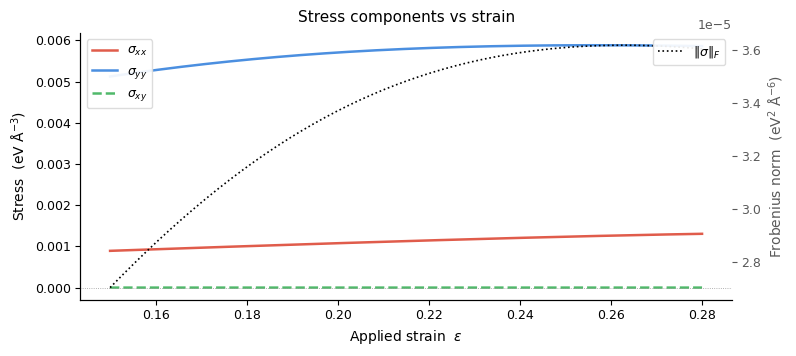

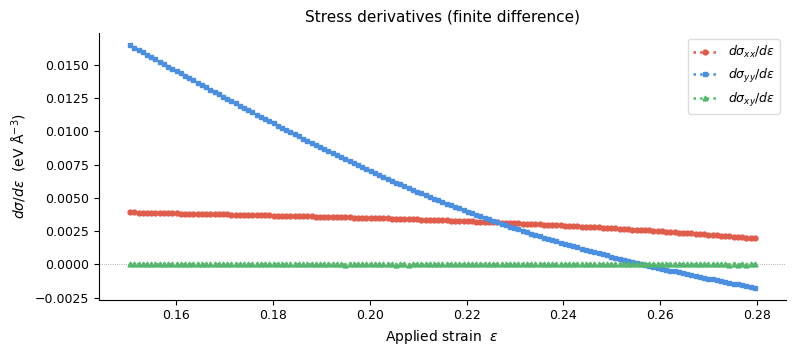

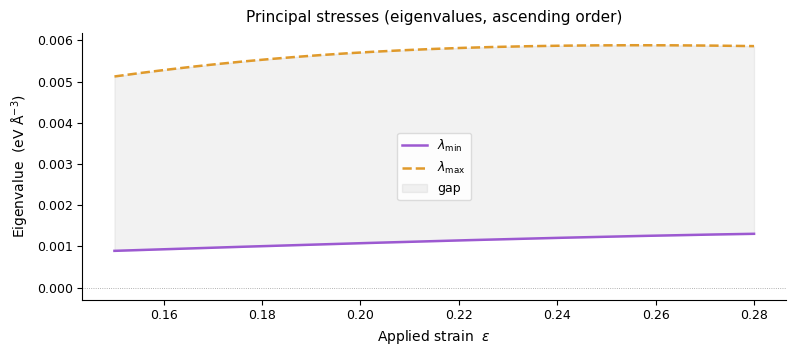

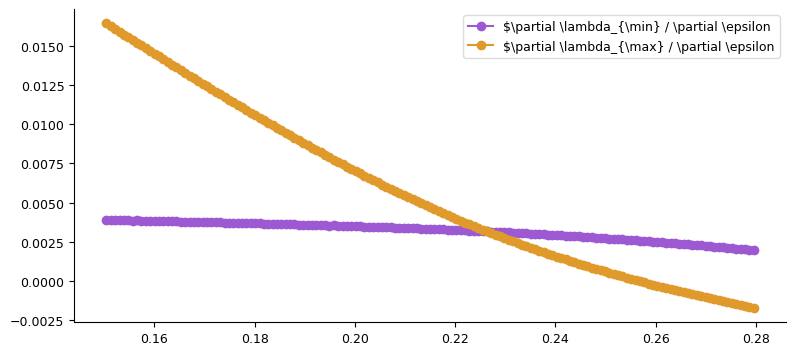

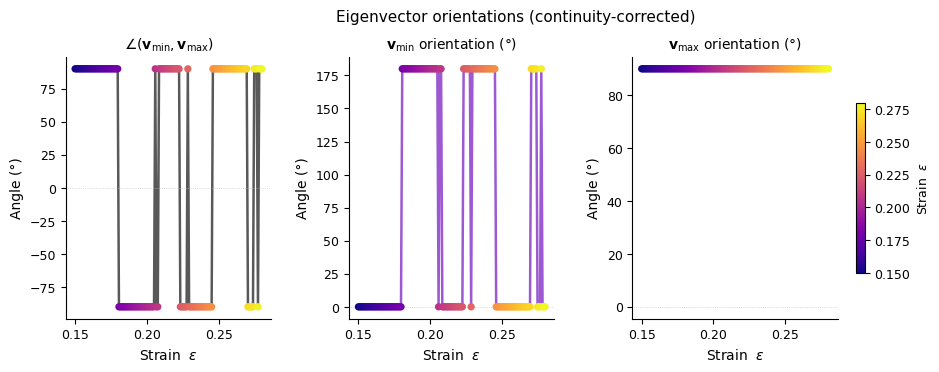

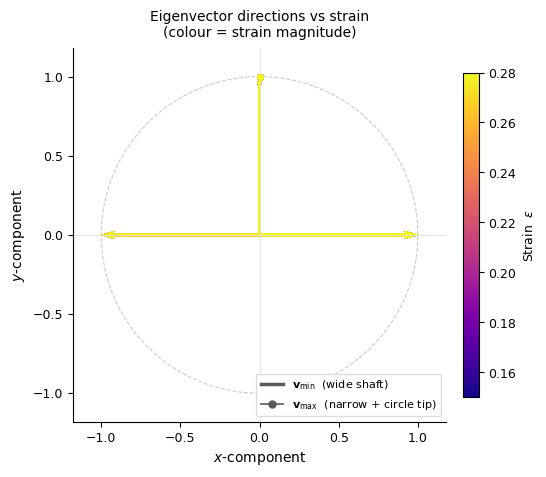

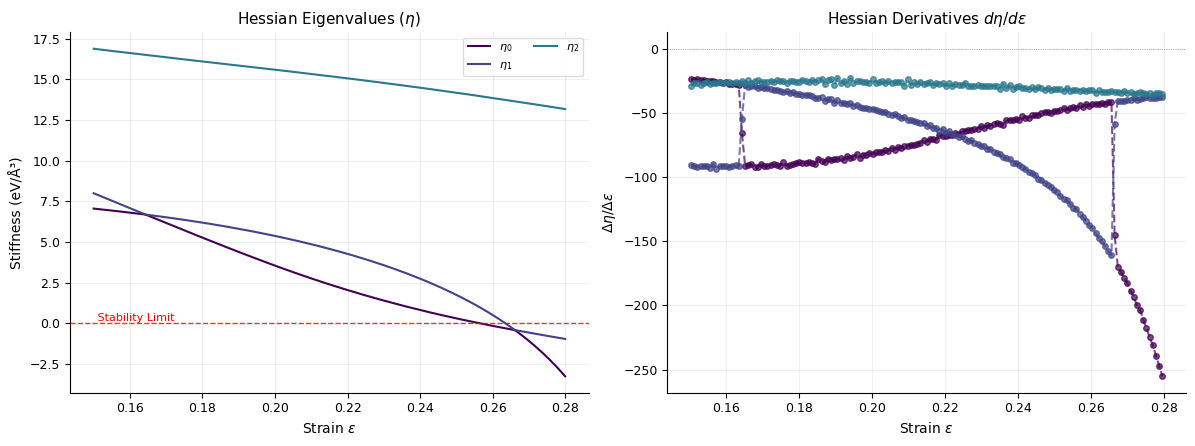

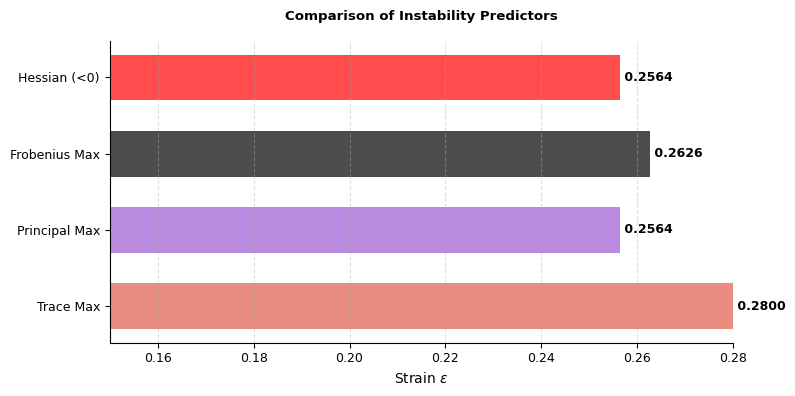

In [21]:
stress_strain(STRAINYY, katoms, strains);

strain loop: 100%|██████████| 150/150 [04:46<00:00,  1.91s/it]


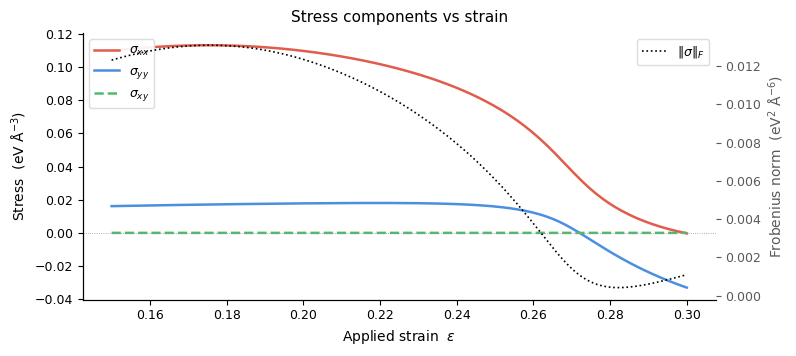

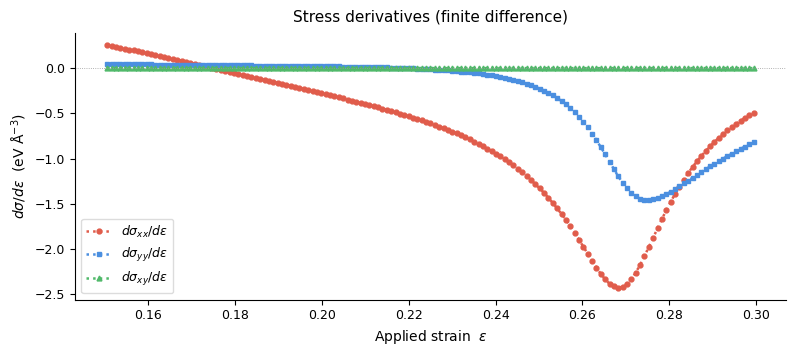

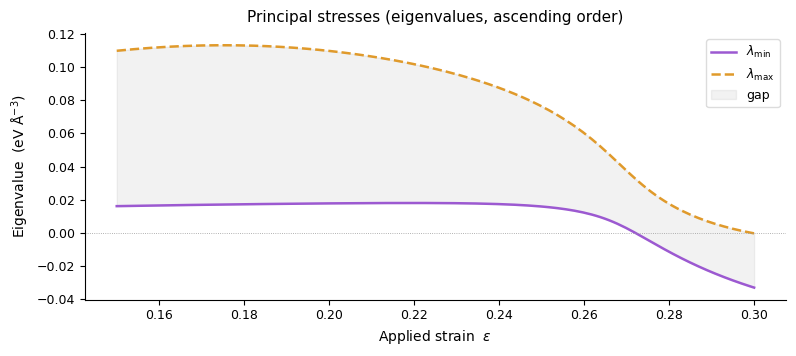

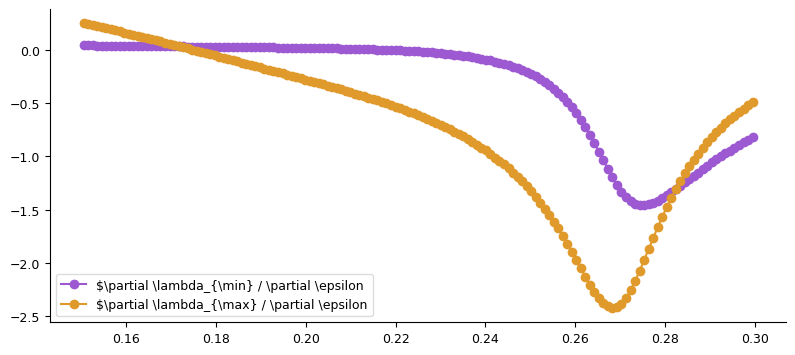

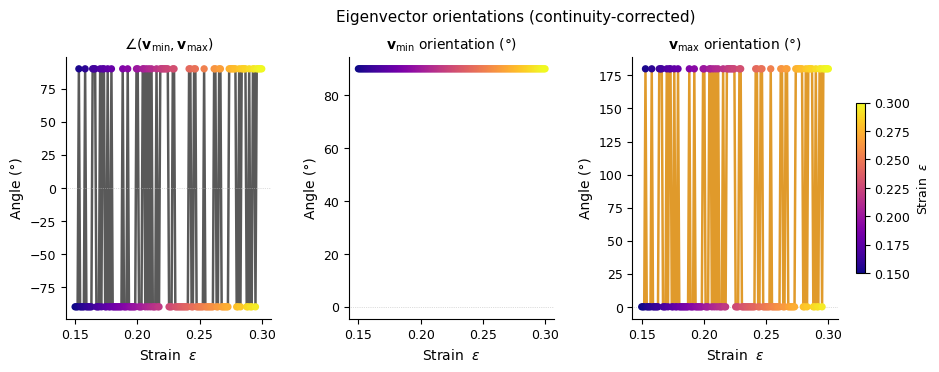

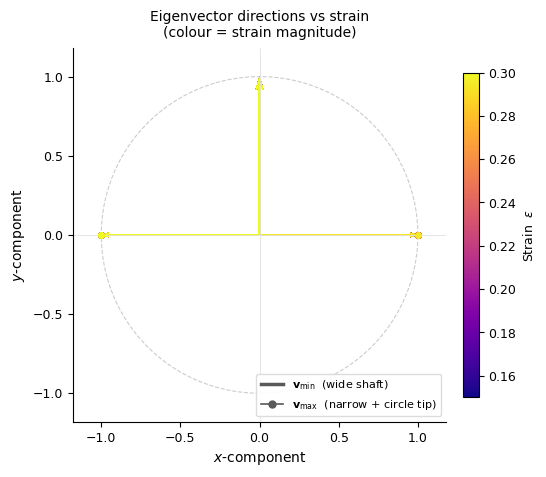

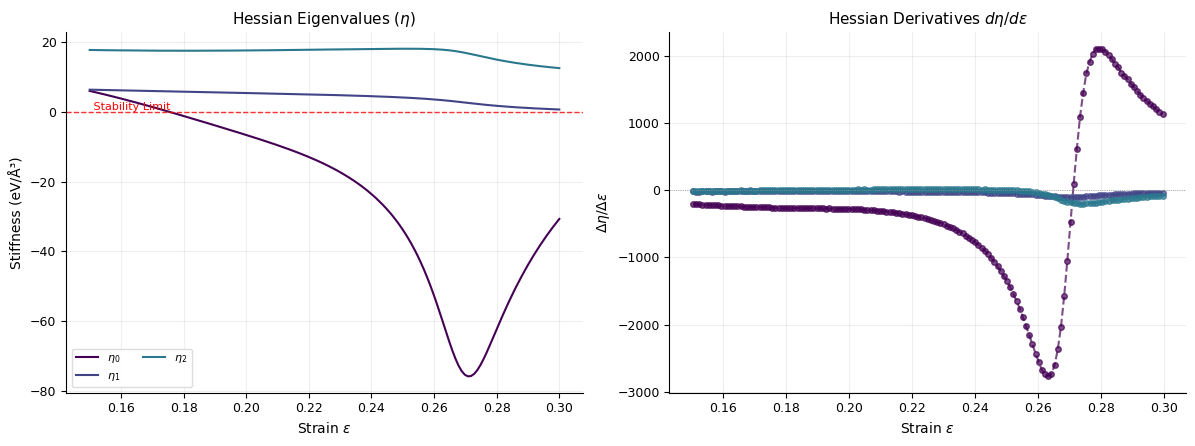

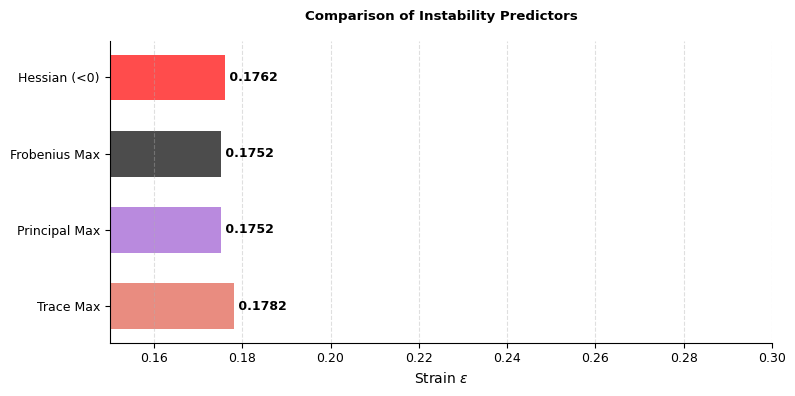

In [ ]:
stress_strain(STRAINXX, primitive, strains);

strain loop: 100%|██████████| 150/150 [02:56<00:00,  1.17s/it]


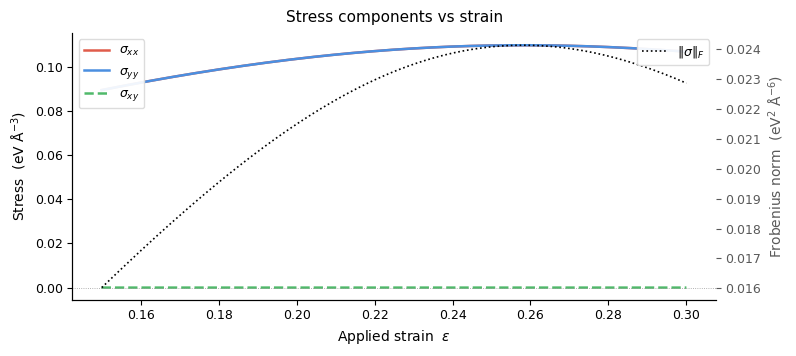

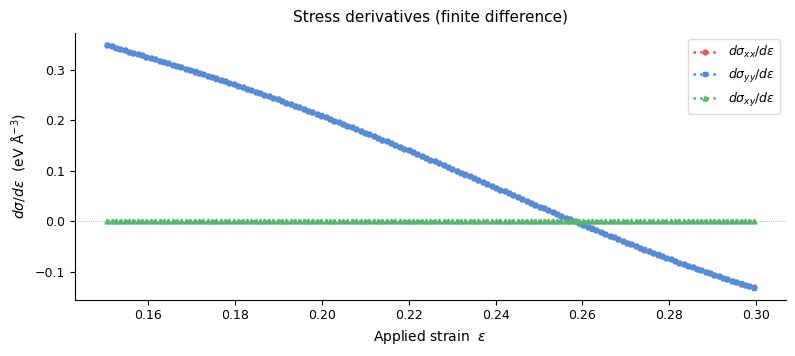

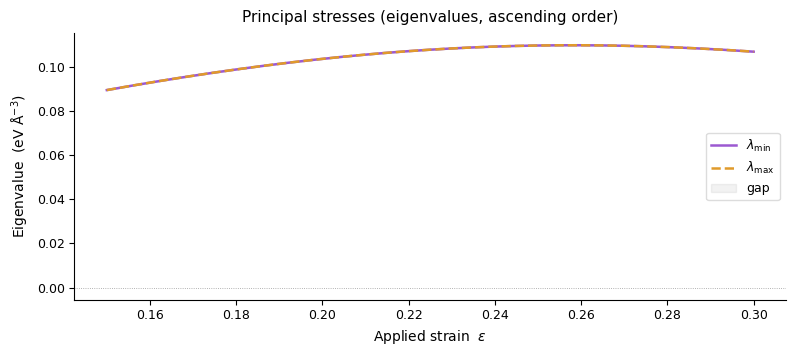

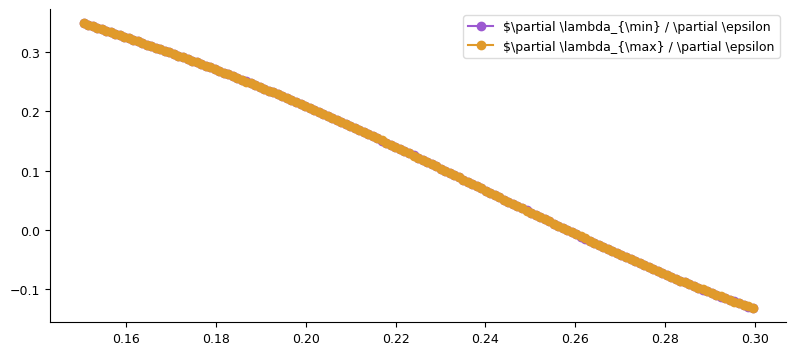

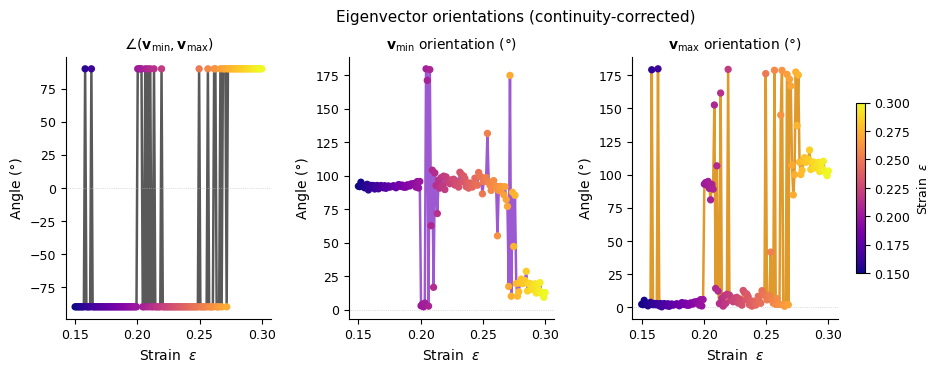

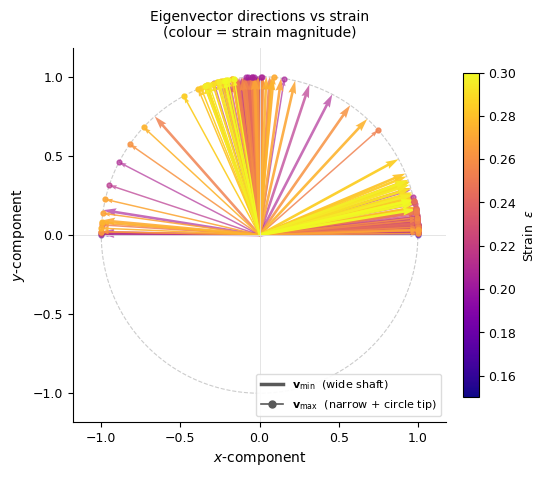

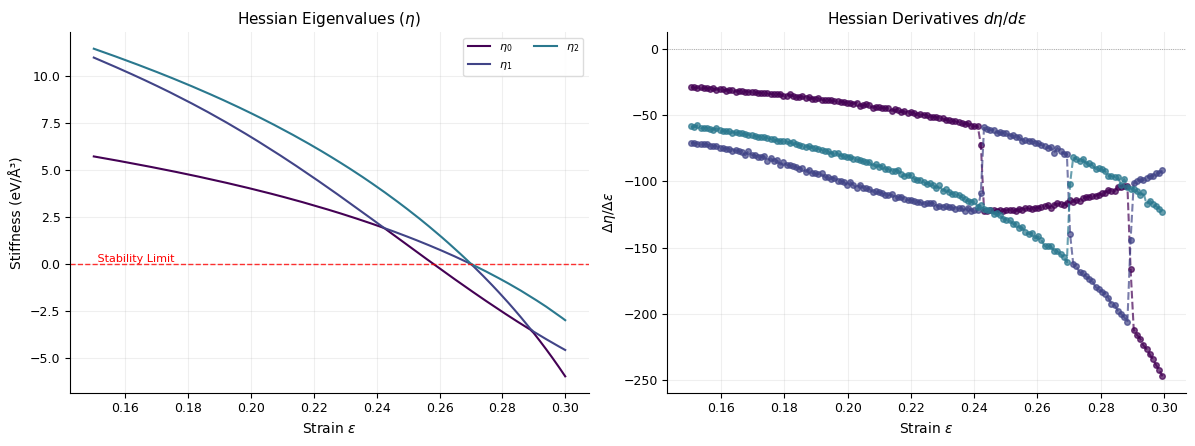

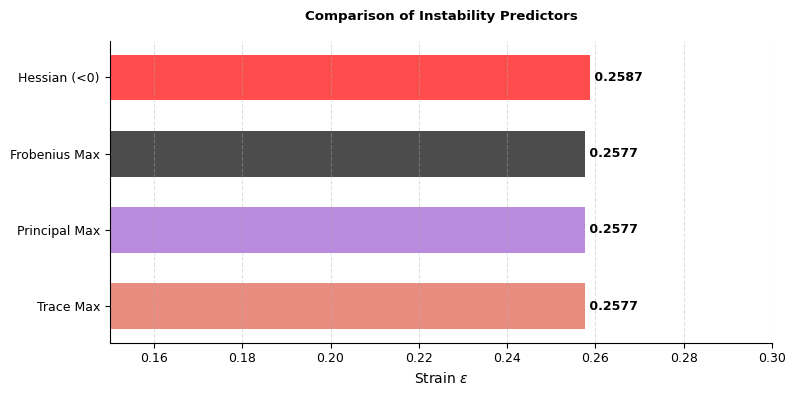

In [ ]:
stress_strain(STRAINEQUI, primitive, strains);

In [ ]:
strain = np.array([
    [1,0,0],
    [0,0,0],
    [0,0,0]
])

amplitude = 0. 

deformation = np.eye(3) + strain

hessian = hessian_2d(primitive, model, 1e-5)

In [ ]:
eval, evect = np.linalg.eig(hessian)

In [ ]:
evect[:,0]

array([0.71050934, 0.70368502, 0.00196665])

In [ ]:
eval

array([5.1712267 , 3.55495483, 1.74421694])

100%|██████████| 11/11 [00:01<00:00,  6.14it/s]


Text(0.5, 1.0, 'Energy vs. Lattice Scaling')

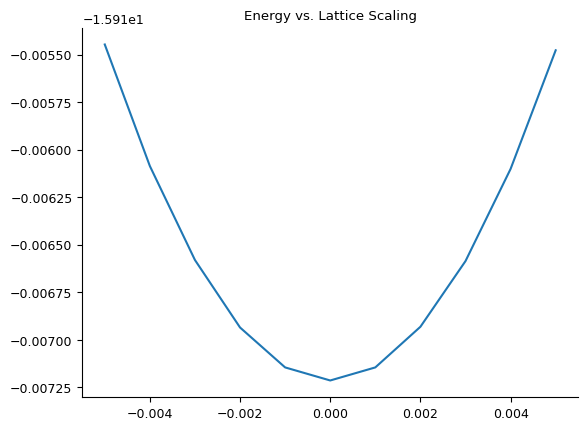

In [ ]:
scales = np.linspace(-5e-3, 5e-3, 11)
energies = []
cell0 = primitive.get_cell().copy()
direction = evect[:,0] @ VOIGT_BASIS_2D # direc

for s in tqdm(scales):
    atoms = primitive.copy()
    atoms.calc=model

    deformation = np.eye(3) + s * direction

    atoms.set_cell(cell0 @ deformation, scale_atoms=True)
    opt = BFGS(atoms, logfile=None)
    opt.run(fmax=1e-5)
    energies.append(atoms.get_potential_energy())

plt.plot(scales, energies)
plt.title("Energy vs. Lattice Scaling")

In [ ]:
steps = np.geomspace(1e-7, 0.1, num = 50)
hessians = []
for step in tqdm(steps):
    hessians.append(hessian_2d(primitive, model, step))

h_vals = np.linalg.eigvalsh(hessians)

100%|██████████| 50/50 [06:18<00:00,  7.57s/it]


In [ ]:
steps

array([1.00000000e-07, 1.32571137e-07, 1.75751062e-07, 2.32995181e-07,
       3.08884360e-07, 4.09491506e-07, 5.42867544e-07, 7.19685673e-07,
       9.54095476e-07, 1.26485522e-06, 1.67683294e-06, 2.22299648e-06,
       2.94705170e-06, 3.90693994e-06, 5.17947468e-06, 6.86648845e-06,
       9.10298178e-06, 1.20679264e-05, 1.59985872e-05, 2.12095089e-05,
       2.81176870e-05, 3.72759372e-05, 4.94171336e-05, 6.55128557e-05,
       8.68511374e-05, 1.15139540e-04, 1.52641797e-04, 2.02358965e-04,
       2.68269580e-04, 3.55648031e-04, 4.71486636e-04, 6.25055193e-04,
       8.28642773e-04, 1.09854114e-03, 1.45634848e-03, 1.93069773e-03,
       2.55954792e-03, 3.39322177e-03, 4.49843267e-03, 5.96362332e-03,
       7.90604321e-03, 1.04811313e-02, 1.38949549e-02, 1.84206997e-02,
       2.44205309e-02, 3.23745754e-02, 4.29193426e-02, 5.68986603e-02,
       7.54312006e-02, 1.00000000e-01])

reference step 0.0019306977288832496


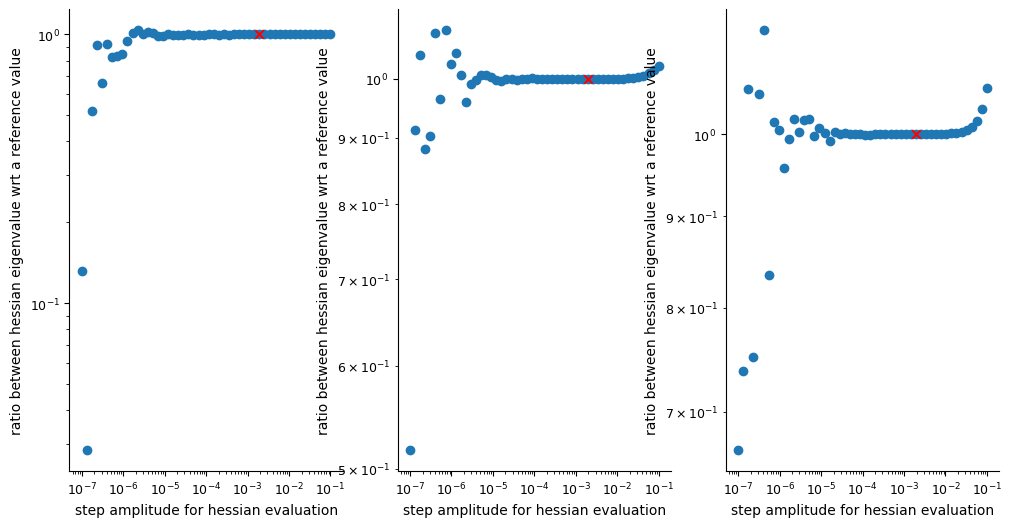

In [ ]:
fig, axs = plt.subplots(1, 3, figsize = (12, 6))
# axs[0].set_ylim(1.75, 1.8)
# axs[1].set_ylim(3.5, 3.6)
# axs[2].set_ylim(5.1, 5.3)

reference_index = -15
print("reference step", steps[reference_index])

for i in range(3):
    axs[i].scatter(steps, h_vals[:,i] / h_vals[reference_index,i])
    axs[i].set_xscale("log")
    axs[i].set_yscale("log")

    axs[i].scatter(steps[reference_index], 1, marker = "x", color = "red")
    axs[i].set_xlabel("step amplitude for hessian evaluation")

    axs[i].set_ylabel("ratio between hessian eigenvalue wrt a reference value")



plt.show()